<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Data Normalization Techniques**


Estimated time needed: **30** minutes


In this lab, you will focus on data normalization. This includes identifying compensation-related columns, applying normalization techniques, and visualizing the data distributions.


## Objectives


In this lab, you will perform the following:


- Identify duplicate rows and remove them.

- Check and handle missing values in key columns.

- Identify and normalize compensation-related columns.

- Visualize the effect of normalization techniques on data distributions.


-----


## Hands on Lab


#### Step 1: Install and Import Libraries


In [1]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 105.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 189.1 MB/s eta 0:00:00


In [2]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 155.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 108.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 84.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 140.7 MB/s eta 0:00:00


In [3]:
import pandas as pd
import matplotlib.pyplot as plt

### Step 2: Load the Dataset into a DataFrame


We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.


The functions below will download the dataset into your browser:


In [4]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)

# Display the first few rows to check if data is loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

In [ ]:
#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")

### Section 1: Handling Duplicates
##### Task 1: Identify and remove duplicate rows.


In [5]:
## Write your code here
# Task 1: Identify and remove duplicate rows

print("Shape before removing duplicates:", df.shape)

dup_rows = df.duplicated().sum()
print("Number of duplicate rows:", dup_rows)

# Remove duplicates
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)
print("Remaining duplicate rows:", df.duplicated().sum())

Shape before removing duplicates: (65437, 114)
Number of duplicate rows: 0
Shape after removing duplicates: (65437, 114)
Remaining duplicate rows: 0


### Section 2: Handling Missing Values
##### Task 2: Identify missing values in `CodingActivities`.


In [6]:
## Write your code here
# Task 2: Identify missing values in CodingActivities

missing_coding = df["CodingActivities"].isna().sum()
total_rows = len(df)

print("Missing values in CodingActivities:", missing_coding)
print("Percent missing:", round((missing_coding / total_rows) * 100, 2), "%")

Missing values in CodingActivities: 10971
Percent missing: 16.77 %


##### Task 3: Impute missing values in CodingActivities with forward-fill.


In [7]:
## Write your code here
# Task 3: Impute missing values in CodingActivities with forward-fill

print("Missing before:", df["CodingActivities"].isna().sum())

df["CodingActivities"] = df["CodingActivities"].ffill()

print("Missing after:", df["CodingActivities"].isna().sum())

Missing before: 10971
Missing after: 0


**Note**:  Before normalizing ConvertedCompYearly, ensure that any missing values (NaN) in this column are handled appropriately. You can choose to either drop the rows containing NaN or replace the missing values with a suitable statistic (e.g., median or mean).


### Section 3: Normalizing Compensation Data
##### Task 4: Identify compensation-related columns, such as ConvertedCompYearly.
Normalization is commonly applied to compensation data to bring values within a comparable range. Here, you’ll identify ConvertedCompYearly or similar columns, which contain compensation information. This column will be used in the subsequent tasks for normalization.


In [8]:
## Write your code here
# Task 4: Identify compensation-related columns

comp_cols = [c for c in df.columns if "Comp" in c]
print("Compensation-related columns:", comp_cols)

# Focus column used for normalization
print("Missing ConvertedCompYearly:", df["ConvertedCompYearly"].isna().sum())
print(df["ConvertedCompYearly"].describe())

Compensation-related columns: ['CompTotal', 'AIComplex', 'ConvertedCompYearly']
Missing ConvertedCompYearly: 42002
count    2.343500e+04
mean     8.615529e+04
std      1.867570e+05
min      1.000000e+00
25%      3.271200e+04
50%      6.500000e+04
75%      1.079715e+05
max      1.625660e+07
Name: ConvertedCompYearly, dtype: float64


##### Task 5: Normalize ConvertedCompYearly using Min-Max Scaling.
Min-Max Scaling brings all values in a column to a 0-1 range, making it useful for comparing data across different scales. Here, you will apply Min-Max normalization to the ConvertedCompYearly column, creating a new column ConvertedCompYearly_MinMax with normalized values.


In [9]:
## Write your code here
# Task 5: Min-Max Scaling for ConvertedCompYearly

min_val = df["ConvertedCompYearly"].min(skipna=True)
max_val = df["ConvertedCompYearly"].max(skipna=True)

df["ConvertedCompYearly_MinMax"] = (df["ConvertedCompYearly"] - min_val) / (max_val - min_val)

df["ConvertedCompYearly_MinMax"].describe()

count    23435.000000
mean         0.005300
std          0.011488
min          0.000000
25%          0.002012
50%          0.003998
75%          0.006642
max          1.000000
Name: ConvertedCompYearly_MinMax, dtype: float64

##### Task 6: Apply Z-score Normalization to `ConvertedCompYearly`.

Z-score normalization standardizes values by converting them to a distribution with a mean of 0 and a standard deviation of 1. This method is helpful for datasets with a Gaussian (normal) distribution. Here, you’ll calculate Z-scores for the ConvertedCompYearly column, saving the results in a new column ConvertedCompYearly_Zscore.


In [10]:
## Write your code here
# Task 6: Z-score Normalization for ConvertedCompYearly

mean_val = df["ConvertedCompYearly"].mean(skipna=True)
std_val = df["ConvertedCompYearly"].std(skipna=True)

df["ConvertedCompYearly_Zscore"] = (df["ConvertedCompYearly"] - mean_val) / std_val

df["ConvertedCompYearly_Zscore"].describe()

count    2.343500e+04
mean     1.637265e-17
std      1.000000e+00
min     -4.613176e-01
25%     -2.861649e-01
50%     -1.132771e-01
75%      1.168161e-01
max      8.658551e+01
Name: ConvertedCompYearly_Zscore, dtype: float64

### Section 4: Visualization of Normalized Data
##### Task 7: Visualize the distribution of `ConvertedCompYearly`, `ConvertedCompYearly_Normalized`, and `ConvertedCompYearly_Zscore`

Visualization helps you understand how normalization changes the data distribution. In this task, create histograms for the original ConvertedCompYearly, as well as its normalized versions (ConvertedCompYearly_MinMax and ConvertedCompYearly_Zscore). This will help you compare how each normalization technique affects the data range and distribution.


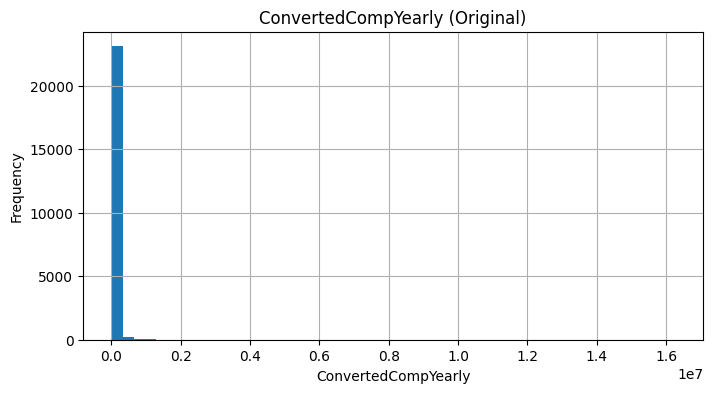

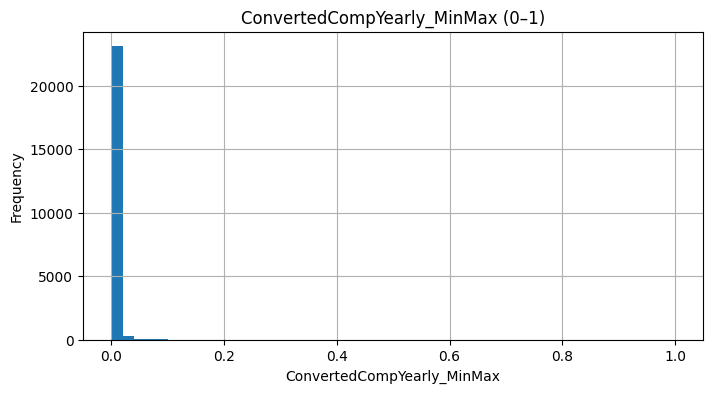

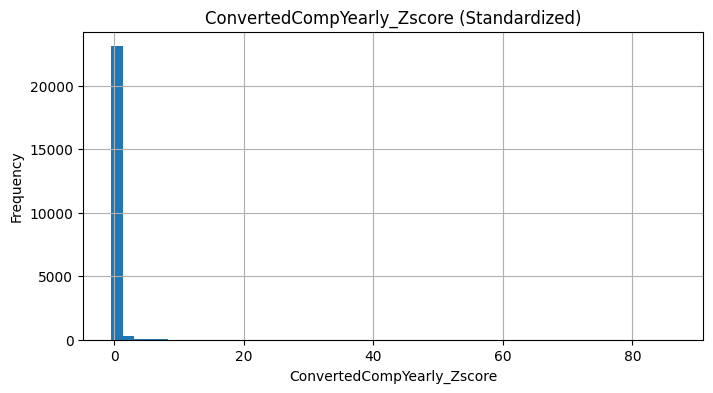

In [11]:
## Write your code here
# Task 7: Visualize distributions

# Original
plt.figure(figsize=(8,4))
df["ConvertedCompYearly"].dropna().hist(bins=50)
plt.title("ConvertedCompYearly (Original)")
plt.xlabel("ConvertedCompYearly")
plt.ylabel("Frequency")
plt.show()

# Min-Max
plt.figure(figsize=(8,4))
df["ConvertedCompYearly_MinMax"].dropna().hist(bins=50)
plt.title("ConvertedCompYearly_MinMax (0–1)")
plt.xlabel("ConvertedCompYearly_MinMax")
plt.ylabel("Frequency")
plt.show()

# Z-score
plt.figure(figsize=(8,4))
df["ConvertedCompYearly_Zscore"].dropna().hist(bins=50)
plt.title("ConvertedCompYearly_Zscore (Standardized)")
plt.xlabel("ConvertedCompYearly_Zscore")
plt.ylabel("Frequency")
plt.show()

### Summary


In this lab, you practiced essential normalization techniques, including:

- Identifying and handling duplicate rows.

- Checking for and imputing missing values.

- Applying Min-Max scaling and Z-score normalization to compensation data.

- Visualizing the impact of normalization on data distribution.


Copyright © IBM Corporation. All rights reserved.
